Columns: Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')


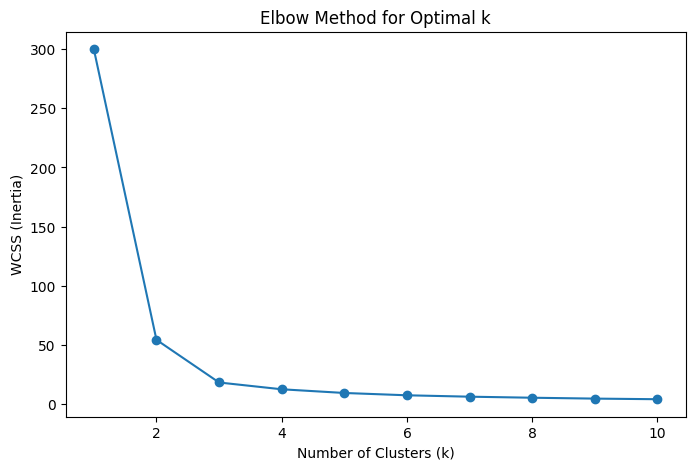

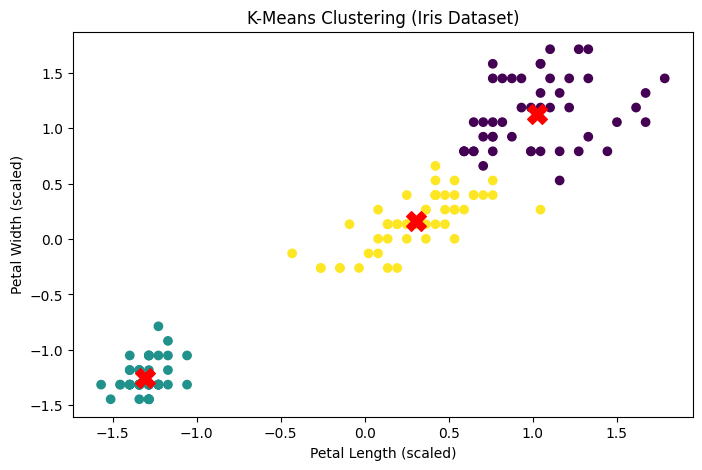

Cluster Centers (scaled):
 [[ 1.02813193  1.12749028]
 [-1.30487835 -1.25512862]
 [ 0.30564587  0.16609419]]


In [1]:
# K-Means Clustering on Iris Dataset

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv("iris.csv")

# Display columns
print("Columns:", df.columns)

# Use only petal length and petal width
# (adjust column names if needed based on your dataset)
X = df[['petal_length', 'petal_width']]

# -------------------------------
# Preprocessing (Scaling)
# -------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------------------
# Elbow Method
# -------------------------------
wcss = []  # Within-cluster sum of squares

K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot Elbow Graph
plt.figure(figsize=(8,5))
plt.plot(K_range, wcss, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS (Inertia)")
plt.title("Elbow Method for Optimal k")
plt.show()

# -------------------------------
# Train Final Model (choose k from elbow, typically 3)
# -------------------------------
optimal_k = 3  # change based on elbow plot

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X_scaled)

# Add cluster labels to dataframe
df['Cluster'] = y_kmeans

# -------------------------------
# Visualization
# -------------------------------
plt.figure(figsize=(8,5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_kmeans, cmap='viridis')

# Plot centroids
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], s=200, c='red', marker='X')

plt.xlabel("Petal Length (scaled)")
plt.ylabel("Petal Width (scaled)")
plt.title("K-Means Clustering (Iris Dataset)")
plt.show()

# Print cluster centers
print("Cluster Centers (scaled):\n", centroids)